### Libraries

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import openpyxl
from colombian_holidays import is_holiday

### Data:

In [4]:
DATA_PATH = "tasas_BRL_COP_CHI_1993-2025.csv"
DATA_RATES_PATH = "rates_interbanks_COL_CHI_BRL_USD_1990-2026.xlsx"

def load_csv(path):
    return pd.read_csv(path)


def load_xlsx(path):
    return pd.read_excel(io=path, sheet_name=None)

### Datos iniciales:

In [28]:
df_cop_usd = load_csv(DATA_PATH)

df_cop_usd['Date'] = pd.to_datetime(df_cop_usd['Date'], errors='coerce')

df_cop_usd.head()

,Date,Rate_BRL,Rate_CHI,Rate_COP
0,1993-01-01,0.0045,382.33,735.00
1,1993-01-04,0.0046,383.57,737.98
2,1993-01-05,0.0046,383.64,737.98
3,1993-01-06,0.0047,383.32,737.98
4,1993-01-07,0.0047,383.59,737.98


In [11]:
df_rates = load_xlsx(DATA_RATES_PATH)["Hoja1"]

df_rates["Dates"] = pd.to_datetime(df_rates["Dates"])

df_rates.rename(columns={"Dates": "Date"}, inplace=True)

df_rates.head(10)

,Date,SOFRRATE Index,CHOVCHOV Index,BZDIOVRA Index,DTF RATE Index,COOVIBR Index
0,1990-01-01,NaN,NaN,NaN,34.87,NaN
1,1990-01-02,NaN,NaN,NaN,34.87,NaN
2,1990-01-03,NaN,NaN,NaN,34.87,NaN
3,1990-01-04,NaN,NaN,NaN,34.87,NaN
4,1990-01-05,NaN,NaN,NaN,34.87,NaN
5,1990-01-08,NaN,NaN,NaN,35.47,NaN
6,1990-01-09,NaN,NaN,NaN,35.47,NaN
7,1990-01-10,NaN,NaN,NaN,35.47,NaN
8,1990-01-11,NaN,NaN,NaN,35.47,NaN
9,1990-01-12,NaN,NaN,NaN,35.47,NaN


In [12]:
df_rates[["SOFRRATE Index", "CHOVCHOV Index", "BZDIOVRA Index", "COOVIBR Index"]].describe()

,SOFRRATE Index,CHOVCHOV Index,BZDIOVRA Index,COOVIBR Index
count,2106.000000,6448.000000,8301.000000,4779.000000
mean,2.639297,4.117556,16.330019,5.724044
std,1.959903,2.442181,12.794632,2.943620
min,0.010000,0.500000,1.900000,1.614000
25%,0.270000,2.500000,10.310000,3.632500
50%,2.400000,3.500000,13.640000,4.395000
75%,4.370000,5.000000,18.750000,8.606000
max,5.400000,11.250000,173.460000,12.353000


In [15]:
df_nonNan = df_rates.dropna(subset=["SOFRRATE Index", "CHOVCHOV Index", "BZDIOVRA Index", "COOVIBR Index"])

df_nonNan[["SOFRRATE Index", "CHOVCHOV Index", "BZDIOVRA Index", "COOVIBR Index"]].describe()

,SOFRRATE Index,CHOVCHOV Index,BZDIOVRA Index,COOVIBR Index
count,2106.000000,2106.000000,2106.000000,2106.000000
mean,2.639297,4.699668,9.103324,6.596219
std,1.959903,3.439426,4.389759,3.704183
min,0.010000,0.500000,1.900000,1.614000
25%,0.270000,2.000000,5.900000,3.983750
50%,2.400000,4.500000,10.400000,4.806000
75%,4.370000,6.500000,13.650000,9.642000
max,5.400000,11.250000,14.900000,12.353000


In [16]:
df_rates_2019_2025 = df_rates[(df_rates["Date"] >= "2019-01-01") & (df_rates["Date"] <= "2025-12-31")]

df_rates_2019_2025[["SOFRRATE Index", "CHOVCHOV Index", "BZDIOVRA Index", "COOVIBR Index"]].describe()

,SOFRRATE Index,CHOVCHOV Index,BZDIOVRA Index,COOVIBR Index
count,1827.000000,1827.000000,1827.000000,1827.000000
mean,2.663295,4.937466,9.134537,6.725088
std,2.080699,3.617941,4.465557,3.836199
min,0.010000,0.500000,1.900000,1.614000
25%,0.090000,1.750000,4.900000,3.463000
50%,2.430000,5.000000,10.650000,7.083000
75%,4.565000,7.250000,13.650000,10.248500
max,5.400000,11.250000,14.900000,12.353000


### Plot:

In [17]:
df = df_rates_2019_2025.copy()

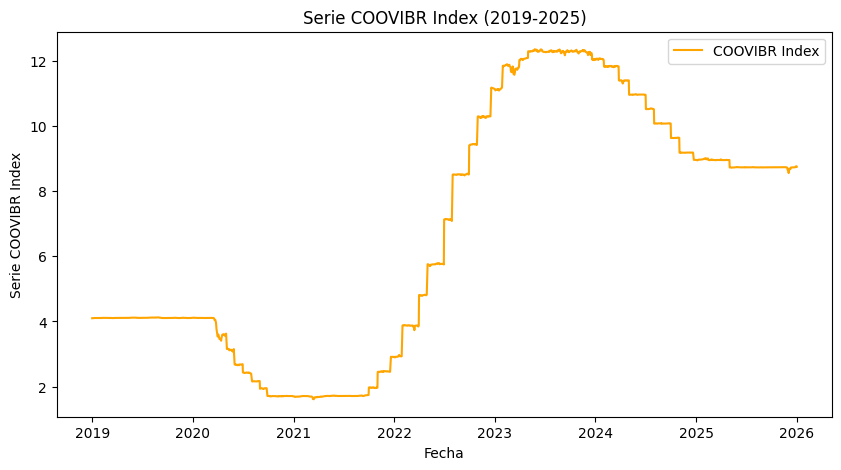

In [18]:
plt.figure(figsize=(10, 5))
plt.plot(df["Date"], df["COOVIBR Index"], label='COOVIBR Index', color='orange')

plt.title('Serie COOVIBR Index (2019-2025)')
plt.xlabel('Fecha')
plt.ylabel('Serie COOVIBR Index')
plt.legend()
plt.show()

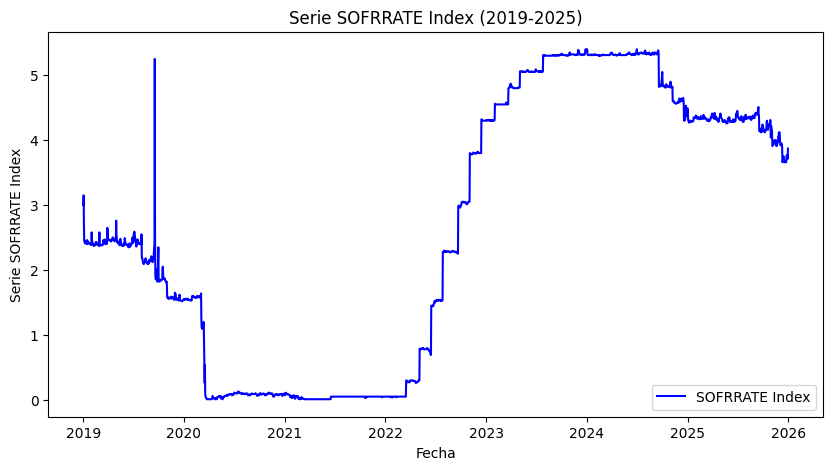

In [19]:
plt.figure(figsize=(10, 5))
plt.plot(df["Date"], df["SOFRRATE Index"], label='SOFRRATE Index', color='blue')

plt.title('Serie SOFRRATE Index (2019-2025)')
plt.xlabel('Fecha')
plt.ylabel('Serie SOFRRATE Index')
plt.legend()
plt.show()

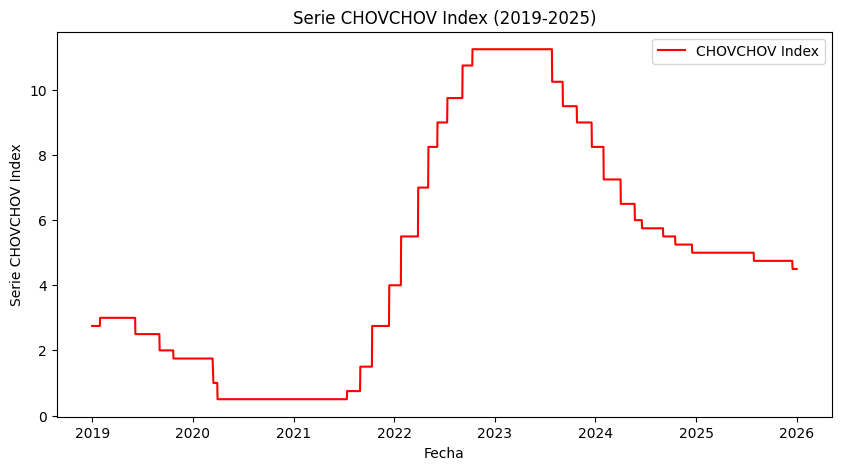

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(df["Date"], df["CHOVCHOV Index"], label='CHOVCHOV Index', color='red')

plt.title('Serie CHOVCHOV Index (2019-2025)')
plt.xlabel('Fecha')
plt.ylabel('Serie CHOVCHOV Index')
plt.legend()
plt.show()

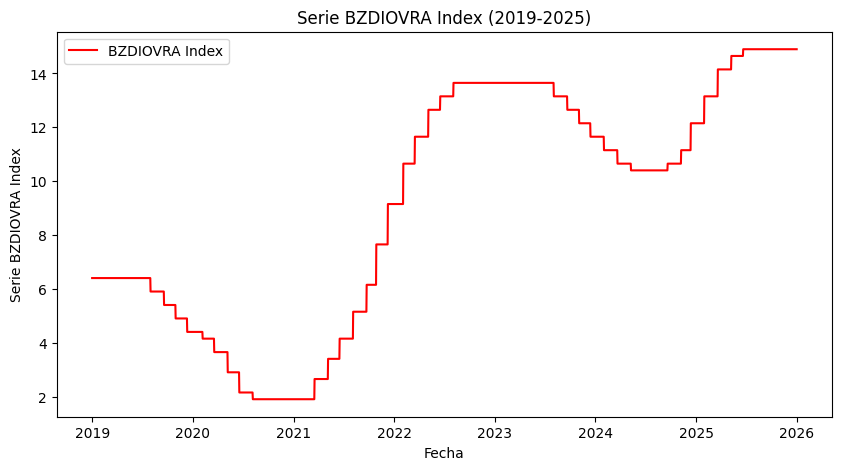

In [21]:
plt.figure(figsize=(10, 5))
plt.plot(df["Date"], df["BZDIOVRA Index"], label='BZDIOVRA Index', color='red')

plt.title('Serie BZDIOVRA Index (2019-2025)')
plt.xlabel('Fecha')
plt.ylabel('Serie BZDIOVRA Index')
plt.legend()
plt.show()

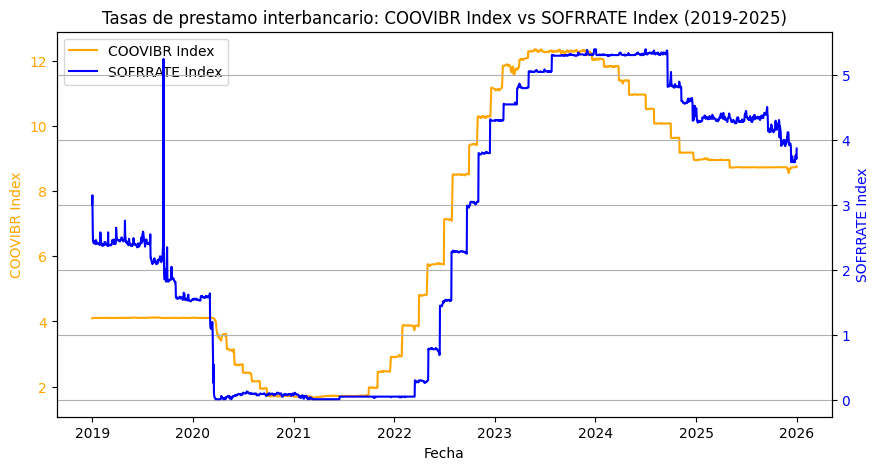

In [24]:
fig, ax1 = plt.subplots(figsize=(10, 5))

# 1ERA SERIE (eje izquierdo)
ax1.plot(df["Date"], df["COOVIBR Index"], color="orange", label="COOVIBR Index")
ax1.set_ylabel("COOVIBR Index", color="orange")
ax1.tick_params(axis="y", labelcolor="orange")

# 2DA SERIE (eje derecho)
ax2 = ax1.twinx()
ax2.plot(df["Date"], df["SOFRRATE Index"], color="blue", label="SOFRRATE Index")
ax2.set_ylabel("SOFRRATE Index", color="blue")
ax2.tick_params(axis="y", labelcolor="blue")

ax1.set_xlabel("Fecha")
plt.title("Tasas de prestamo interbancario: COOVIBR Index vs SOFRRATE Index (2019-2025)")

# Leyenda combinada
lines = ax1.get_lines() + ax2.get_lines()
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="upper left")

plt.grid(True)
plt.show()

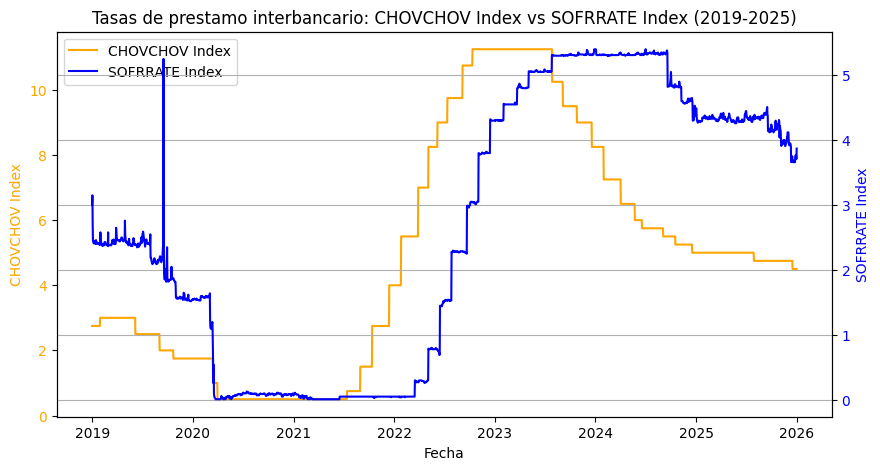

In [25]:
fig, ax1 = plt.subplots(figsize=(10, 5))

# 1ERA SERIE (eje izquierdo)
ax1.plot(df["Date"], df["CHOVCHOV Index"], color="orange", label="CHOVCHOV Index")
ax1.set_ylabel("CHOVCHOV Index", color="orange")
ax1.tick_params(axis="y", labelcolor="orange")

# 2DA SERIE (eje derecho)
ax2 = ax1.twinx()
ax2.plot(df["Date"], df["SOFRRATE Index"], color="blue", label="SOFRRATE Index")
ax2.set_ylabel("SOFRRATE Index", color="blue")
ax2.tick_params(axis="y", labelcolor="blue")

ax1.set_xlabel("Fecha")
plt.title("Tasas de prestamo interbancario: CHOVCHOV Index vs SOFRRATE Index (2019-2025)")

# Leyenda combinada
lines = ax1.get_lines() + ax2.get_lines()
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="upper left")

plt.grid(True)
plt.show()

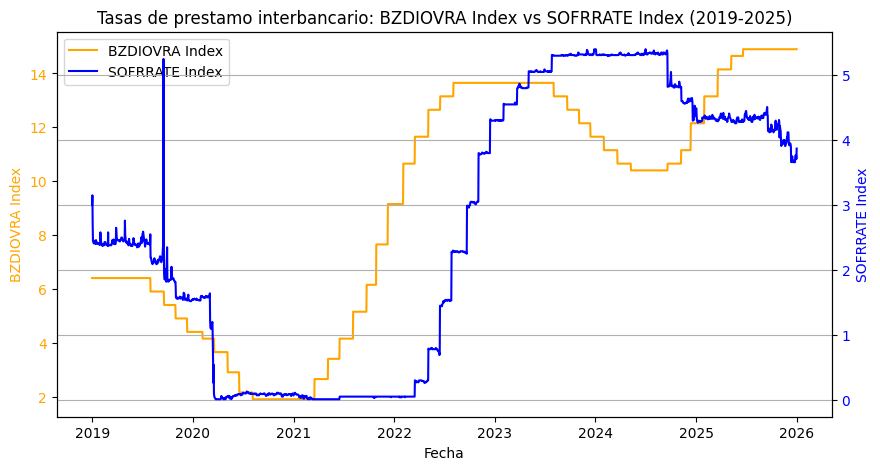

In [26]:
fig, ax1 = plt.subplots(figsize=(10, 5))

# 1ERA SERIE (eje izquierdo)
ax1.plot(df["Date"], df["BZDIOVRA Index"], color="orange", label="BZDIOVRA Index")
ax1.set_ylabel("BZDIOVRA Index", color="orange")
ax1.tick_params(axis="y", labelcolor="orange")

# 2DA SERIE (eje derecho)
ax2 = ax1.twinx()
ax2.plot(df["Date"], df["SOFRRATE Index"], color="blue", label="SOFRRATE Index")
ax2.set_ylabel("SOFRRATE Index", color="blue")
ax2.tick_params(axis="y", labelcolor="blue")

ax1.set_xlabel("Fecha")
plt.title("Tasas de prestamo interbancario: BZDIOVRA Index vs SOFRRATE Index (2019-2025)")

# Leyenda combinada
lines = ax1.get_lines() + ax2.get_lines()
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="upper left")

plt.grid(True)
plt.show()

### Interbank rates + Exchange Rates (Necesaria imputacion de datos faltantes para Gold)

In [29]:
df_rates_interbank = df[["Date", "SOFRRATE Index", "CHOVCHOV Index", "BZDIOVRA Index", "COOVIBR Index"]].copy()

df_rates_interbank = pd.merge(df_rates_interbank, df_cop_usd, on="Date", how="left")

df_rates_interbank.rename(columns={'Últ precio': 'Gold'}, inplace=True)

df_rates_interbank.describe()

,Date,SOFRRATE Index,CHOVCHOV Index,BZDIOVRA Index,COOVIBR Index,Rate_BRL,Rate_CHI,Rate_COP
count,1827,1827.000000,1827.000000,1827.000000,1827.000000,1722.000000,1722.000000,1722.000000
mean,2022-07-01 19:12:18.916256,2.663295,4.937466,9.134537,6.725088,5.087569,837.795285,3916.152480
min,2019-01-01 00:00:00,0.010000,0.500000,1.900000,1.614000,3.646800,649.050000,3071.180000
25%,2020-09-30 12:00:00,0.090000,1.750000,4.900000,3.463000,4.911050,769.752500,3661.782500
50%,2022-07-01 00:00:00,2.430000,5.000000,10.650000,7.083000,5.214400,824.080000,3913.125000
75%,2024-04-01 12:00:00,4.565000,7.250000,13.650000,10.248500,5.476050,930.250000,4149.432500
max,2025-12-31 00:00:00,5.400000,11.250000,14.900000,12.353000,6.293100,1048.500000,5120.150000
std,NaN,2.080699,3.617941,4.465557,3.836199,0.576660,95.114239,416.298017


In [45]:
df_rates_interbank = df_rates_interbank.dropna(
    subset=["Rate_BRL", "Rate_CHI", "Rate_COP"],
    how="all"
)

df_rates_interbank.describe()

,Date,SOFRRATE Index,CHOVCHOV Index,BZDIOVRA Index,COOVIBR Index,Rate_BRL,Rate_CHI,Rate_COP
count,1722,1722.000000,1722.000000,1722.000000,1722.000000,1722.000000,1722.000000,1722.000000
mean,2022-06-28 01:01:02.717770,2.652973,4.925377,9.131417,6.702549,5.087569,837.795285,3916.152480
min,2019-01-02 00:00:00,0.010000,0.500000,1.900000,1.614000,3.646800,649.050000,3071.180000
25%,2020-09-24 06:00:00,0.090000,1.750000,5.150000,3.485000,4.911050,769.752500,3661.782500
50%,2022-06-23 12:00:00,2.430000,4.750000,10.650000,5.778000,5.214400,824.080000,3913.125000
75%,2024-04-01 18:00:00,4.550000,7.250000,13.650000,10.078750,5.476050,930.250000,4149.432500
max,2025-12-30 00:00:00,5.400000,11.250000,14.900000,12.353000,6.293100,1048.500000,5120.150000
std,NaN,2.074209,3.602481,4.452141,3.821224,0.576660,95.114239,416.298017


In [46]:
df_rates_interbank.to_csv("data_ratesIB_exchange_2019-2025.csv", index=False)